# Generic Tuning Interface

In [1]:
from arbok_driver import ArbokDriver, Device, Measurement
from arbok_driver.examples.configurations import opx1000_config

2026-03-23 12:38:23,317 - qm - INFO     - Starting session: dea49ef1-eab0-4342-8ceb-6de8a89f9ab7


In [2]:
from arbok_driver.examples.configurations import (
    device_config, parity_init_conf, parity_read_conf
)

mock_device = Device(
    name = 'mock_device',
    opx_config = opx1000_config,
    divider_config = {},
    master_config = device_config
)

qm_driver = ArbokDriver('qm_driver', mock_device)

mock_measurement = Measurement(qm_driver, 'mock_measurement')

mock_measurement.add_subsequences_from_dict({
    'paraity_init_even': {'config': parity_init_conf},
    'parity_read_even': {'config': parity_read_conf},
    'parity_init_odd': {'config': parity_init_conf},
    'parity_read_odd': {'config': parity_read_conf}
})

In [3]:
from arbok_driver.generic_tunig_interface import CostStrategy

import numpy as np

class CustomStrategy(CostStrategy):
    def get_cost(self, results: dict) -> float:
        return float(np.random.rand())
    
parity_cost_strat = CustomStrategy(
    mock_measurement.available_gettables,
    [{mock_measurement.iteration: np.arange(100)}]
    )

In [4]:
#[g.full_name for g in mock_measurement.available_gettables]

In [5]:
#mock_measurement.print_readable_snapshot()

In [6]:
tuning_interface = mock_measurement.initialize_tuning_interface(
    parameter_dicts = {
        't_ramp_init': {
            'qua_vars': {mock_measurement.parity_init_odd.arbok_params.t_ramp_over_crossing: 1},
            'bounds': (25, 1e4)
            },
        'read_detuning': {
            'qua_vars': {
                mock_measurement.parity_read_even.arbok_params.v_read['P1']: 1,
                mock_measurement.parity_read_even.arbok_params.v_read['P2']: -1,
                mock_measurement.parity_read_odd.arbok_params.v_read['P1']: 1,
                mock_measurement.parity_read_odd.arbok_params.v_read['P2']: -1,
                },
            'bounds': (-0.01, 0.01)
            },
        },
    cost_strategy = parity_cost_strat,
    verbose = True
)

Adding input stream for t_ramp_over_crossing (t_ramp_init)

Adding input stream for v_read_P1 (read_detuning)

Adding v_read_P2 to v_read_P1  input stream (factor: -1) (read_detuning)

Adding v_read_P1 to v_read_P1  input stream (factor: 1) (read_detuning)

Adding v_read_P2 to v_read_P1  input stream (factor: -1) (read_detuning)

Declared 1-dimensional parameter sweep of size 100 [100]
Registered 16 gettables for measurement


In [7]:
mock_measurement.print_qua_program_to_file('test_parity.py')

In [8]:
mock_measurement.parity_read_even.arbok_params.v_read['P1'].qua

In [9]:
mock_measurement.parity_read_even.arbok_params.v_read['P2'].qua

In [10]:
mock_measurement.parity_read_even.arbok_params.v_read['P2'].call_method()

In [11]:
mock_measurement._setpoints_for_gettables[0].vals

<Arrays, shape: (100,)>

In [12]:
mock_measurement.gettables['qm_driver_mock_measurement_parity_read_even_ref__p1p2'].setpoints

(<arbok_driver.parameter_types.Int: iteration at 1522564108976>,)

In [13]:
mock_measurement.tuning_interface.compile_connect_and_run('192.168.88.252')

2026-03-23 12:38:27,076 - qm - INFO     - Performing health check


INFO:qm.api.v2.qmm_api:Performing health check


2026-03-23 12:38:27,082 - qm - INFO     - Cluster healthcheck completed successfully.


INFO:qm.api.v2.qmm_api:Cluster healthcheck completed successfully.
C:\Users\labuser\ekans_base\arbok_driver\.venv\Lib\site-packages\qm\api\v2\qmm_api.py:159: DeprecationWarning: close_other_machines is not set, as from 2.0.0 default will be False, now setting to True. Please set it explicitly to remove this message and keep the wanted behavior in future versions.
  warnings.warn(


2026-03-23 12:38:27,950 - qm - INFO     - Opened quantum machine with id: QM-68bd3684-7867-4cff-adaf-1a755cbdd4ea


...

2026-03-23 12:38:29,584 - qm - INFO     - Adding program to queue.


INFO:qm.api.v2.qm_api:Adding program to queue.


2026-03-23 12:38:32,173 - qm - INFO     - Program added to queue. Job id: 75f67c8f-22d1-4f19-95ad-6acec35adfa5


INFO:qm.api.v2.qm_api:Program added to queue. Job id: 75f67c8f-22d1-4f19-95ad-6acec35adfa5


QUA program compiled and is running


In [19]:
step_dict = {
        mock_measurement.parity_init_odd.arbok_params.t_ramp_over_crossing: 100,
        mock_measurement.parity_read_even.arbok_params.v_read['P1']: 0.1
    }
cost, gettable_results, saved_params = tuning_interface.run_parameter_set(step_dict)

In [20]:
cost

0.4840346772206344

In [ ]:
gettable_results

In [22]:
saved_params

{'t_ramp_init': 100, 'read_detuning': 0.1}

Current bounds:

{'t_ramp_init': (25, 10000.0), 'read_detuning': (-0.01, 0.01)}

Output()

KeyError: <arbok_driver.parameters.gettable_parameter.GettableParameter: ref__p1p2 at 1522564113008>

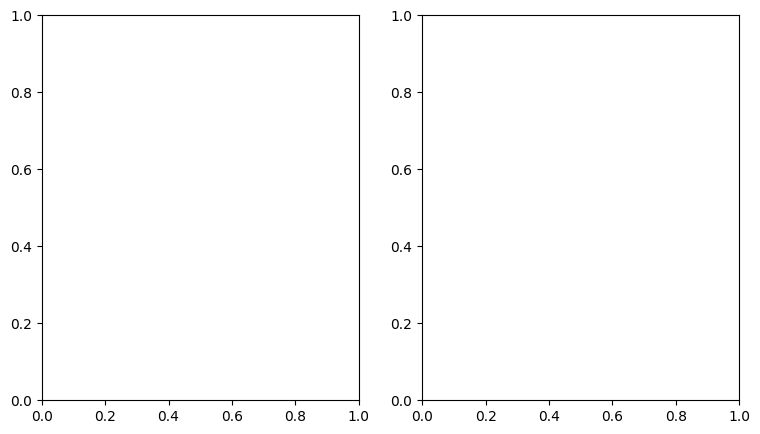

In [23]:
tuning_interface.run_cross_entropy_sampler([20, 10, 10], 0.2, True)

In [24]:
tuning_interface.parameter_dict

{'t_ramp_init': {'qua_vars': {<arbok_driver.parameter_types.Time: t_ramp_over_crossing at 1522565170832>: 1},
  'bounds': (25, 10000.0)},
 'read_detuning': {'qua_vars': {<arbok_driver.parameter_types.Voltage: v_read_P1 at 1522565014672>: 1,
   <arbok_driver.parameter_types.Voltage: v_read_P2 at 1522565015312>: -1,
   <arbok_driver.parameter_types.Voltage: v_read_P1 at 1522565366800>: 1,
   <arbok_driver.parameter_types.Voltage: v_read_P2 at 1522565367440>: -1},
  'bounds': (-0.01, 0.01)}}

In [17]:
from collections import Counter
if Counter(step_dict.keys()) != Counter(mock_measurement.input_stream_parameters):
    print(fail)

In [25]:
{name: [] for name in tuning_interface.parameter_dict.keys()}

{'t_ramp_init': [], 'read_detuning': []}

In [26]:
{g.name: [] for g in tuning_interface.cost_strategy.gettables}

{'ref__p1p2': [],
 'ref__p7p8': [],
 'read__p1p2': [],
 'read__p7p8': [],
 'diff__p1p2': [],
 'diff__p7p8': [],
 'state__p1p2': [],
 'state__p7p8': []}